In [346]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tools.tools import *
from tools.bag_to_df import bag_topic_to_dataframe
import pandas as pd
from scipy.spatial.transform import Rotation as R

%load_ext autoreload
%autoreload 2

REAL_BAG_PATH = "/root/stonefish_ros2_ws/sintef_dataset/2024-08-22_14-29-05_data.bag"
SIM_BAG_PATH = "/root/stonefish_ros2_ws/recorded_data/simulation/rosbag2_2025_11_06-11_06_52"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [285]:
print_bag_topics(REAL_BAG_PATH)

Topics and message types:
/bluerov2/alive                                std_msgs/msg/Float32
/bluerov2/armed                                std_msgs/msg/Float32
/bluerov2/battery                              messages/msg/BatteryStatus
/bluerov2/modes                                joystick/msg/ModeManager2
/commanded_thrust                              rospy_tutorials/msg/Floats
/controller/x                                  messages/msg/MRACOupdate
/controller/y                                  messages/msg/MRACOupdate
/controller/yaw                                messages/msg/PIDState
/controller/z                                  messages/msg/PIDState
/gui/netFollowing_manager                      messages/msg/NetFollowingManager
/guidance                                      messages/msg/GuidanceManager
/joystick                                      joystick/msg/Joystick
/joystick/dvl_reset_position                   messages/msg/BoolStamped
/joystick/init                        

# Read data

In [352]:
# Read data and normalize time

# NUCLEUS
nucleus_ins = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/nucleus1000dvl/ins")

# Add roll pitch yaw to nucleus ins
quats = nucleus_ins[["quaternion.x", "quaternion.y", "quaternion.z", "quaternion.w"]].values
eulers = R.from_quat(quats).as_euler('xyz', degrees=False)
nucleus_ins["roll"] = eulers[:, 0]
nucleus_ins["pitch"] = eulers[:, 1]
nucleus_ins["yaw"] = eulers[:, 2]

nucleus_alitmeter = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/nucleus1000dvl/altimeter")
nucleus_bottomtrack = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/nucleus1000dvl/bottomtrack")
nucleus_magnetometer = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/nucleus1000dvl/magnetometer")
nucleus_watertrack = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/nucleus1000dvl/watertrack")
normalize_time(nucleus_ins)
normalize_time(nucleus_alitmeter)
normalize_time(nucleus_bottomtrack)
normalize_time(nucleus_magnetometer)
normalize_time(nucleus_watertrack)


# A50
dvl_a50_position = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/sensor/dvl_position")
dvl_a50_velocity = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/sensor/dvl_velocity")
normalize_time(dvl_a50_position)
normalize_time(dvl_a50_velocity)

# SIM
sim_dvl = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/dvl")
sim_gt = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/ground_truth")
sim_ins = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/ins")
normalize_time(sim_dvl)
normalize_time(sim_gt)
normalize_time(sim_ins)
print("")

/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:236: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')
/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:236: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')


# Sway Velocity

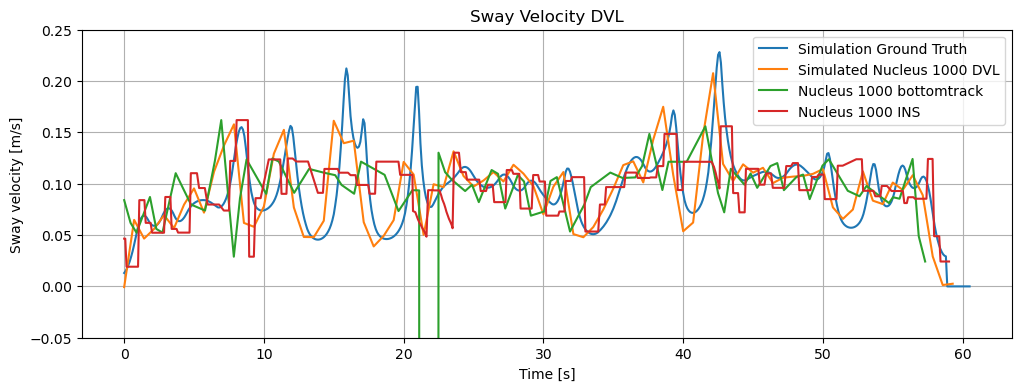

In [368]:
plt.figure(figsize=(12, 4))

# --- GROUND THRUTH ---
plt.plot(sim_gt["t"].values, -sim_gt["twist.twist.linear.y"].values, label="Simulation Ground Truth")

# --- SIMULATED NUCLEUS ---
plt.plot(sim_dvl["t"].values, -sim_dvl["velocity.y"].values, label="Simulated Nucleus 1000 DVL")

# --- NUCLEUS BOTTOMTRACK ---
plt.plot(nucleus_bottomtrack["t"].values, nucleus_bottomtrack["dvl_velocity_xyz.x"].values, label="Nucleus 1000 bottomtrack")

# --- NUCLEUS INS ---
plt.plot(nucleus_ins["t"].values, (nucleus_ins["velocityNucleus.x"].values), label="Nucleus 1000 INS")


# --- DVL-A50 ---
# plt.plot(dvl_a50_velocity["t"].values, dvl_a50_velocity["velocity.x"].values, label="DVL-A50")

plt.title("Sway Velocity DVL")
plt.xlabel("Time [s]")
plt.ylabel("Sway velocity [m/s]")

plt.ylim((-0.05, 0.25))

plt.legend()
plt.grid()


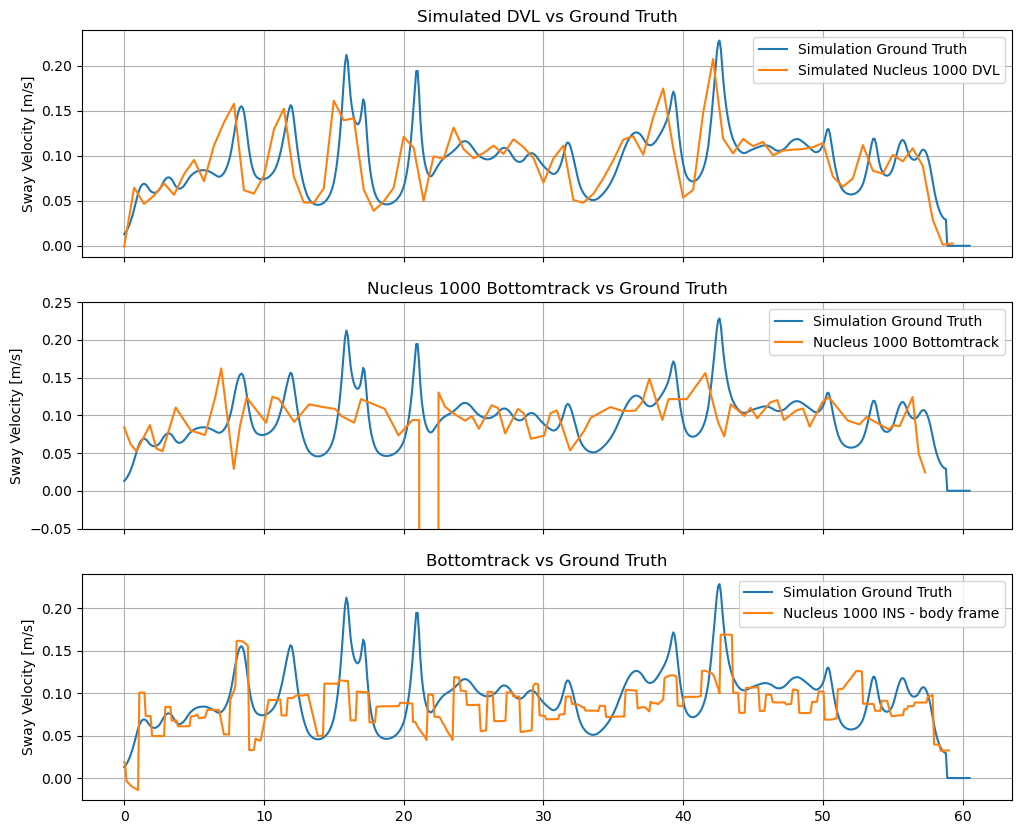

In [382]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(sim_gt["t"].values, -sim_gt["twist.twist.linear.y"].values, label="Simulation Ground Truth")
axes[0].plot(sim_dvl["t"].values, -sim_dvl["velocity.y"].values, label="Simulated Nucleus 1000 DVL")
axes[0].set_title("Simulated DVL vs Ground Truth")
axes[0].set_ylabel("Sway Velocity [m/s]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(sim_gt["t"].values, -sim_gt["twist.twist.linear.y"].values, label="Simulation Ground Truth")
axes[1].plot(nucleus_bottomtrack["t"].values, nucleus_bottomtrack["dvl_velocity_xyz.x"].values, label="Nucleus 1000 Bottomtrack")
axes[1].set_title("Nucleus 1000 Bottomtrack vs Ground Truth")
axes[1].set_ylabel("Sway Velocity [m/s]")
axes[1].legend()
axes[1].set_ylim((-0.05, 0.25))
axes[1].grid(True)

axes[2].plot(sim_gt["t"].values, -sim_gt["twist.twist.linear.y"].values, label="Simulation Ground Truth")
axes[2].plot(nucleus_ins["t"].values, (nucleus_ins["velocityNed.x"].values), label="Nucleus 1000 INS - body frame")
axes[2].set_title("Bottomtrack vs Ground Truth")
axes[2].set_ylabel("Sway Velocity [m/s]")
axes[2].legend()
axes[2].grid(True)


Observerer at ground thruth lagger bak med ca 1/f_dvl.

# Beams

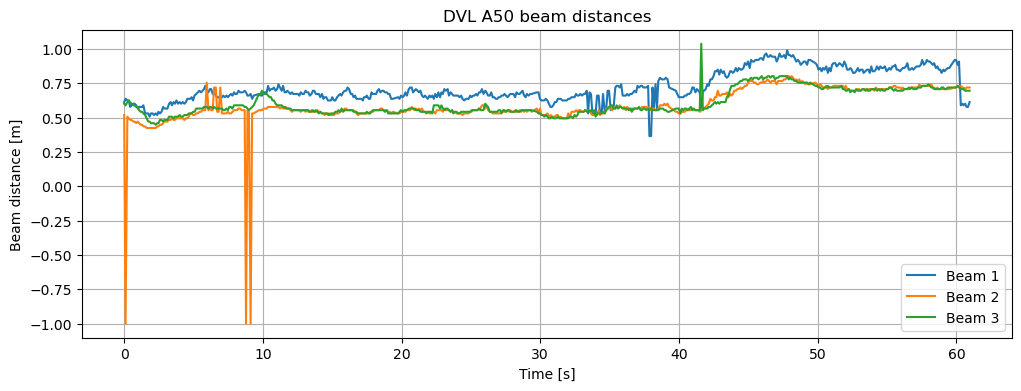

In [361]:
plt.figure(figsize=(12, 4))

# --- DVL-A50 ---
plt.plot(dvl_a50_velocity["t"].values, dvl_a50_velocity["beams.0.distance"].values, label="Beam 1")
plt.plot(dvl_a50_velocity["t"].values, dvl_a50_velocity["beams.1.distance"].values, label="Beam 2")
plt.plot(dvl_a50_velocity["t"].values, dvl_a50_velocity["beams.2.distance"].values, label="Beam 3")

plt.title("DVL A50 beam distances")
plt.xlabel("Time [s]")
plt.ylabel("Beam distance [m]")

# plt.ylim((-0.05, 0.25))

plt.legend()
plt.grid()

# INS angular velocity

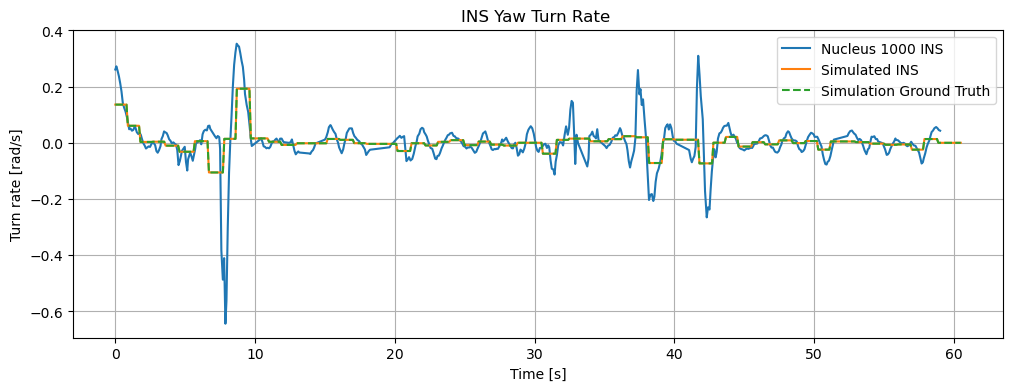

In [362]:
plt.figure(figsize=(12, 4))


v0 = -sim_gt["twist.twist.linear.y"].values[0]
v0 = 0.07
v0 = 0

plt.plot(nucleus_ins["t"].values, -np.deg2rad(nucleus_ins["turnRate.y"].values), label="Nucleus 1000 INS")

plt.plot(sim_ins["t"].values, sim_ins["rpy_rate.z"].values + v0, label="Simulated INS")

plt.plot(sim_gt["t"].values, sim_gt["twist.twist.angular.z"].values, label="Simulation Ground Truth", ls="--")

plt.title("INS Yaw Turn Rate ")
plt.xlabel("Time [s]")
plt.ylabel("Turn rate [rad/s]")

# plt.ylim((-0.05, 0.25))

plt.legend()
plt.grid()

In [363]:
sim_ins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 606 entries, 0 to 605
Data columns (total 37 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   t                          606 non-null    float64
 1   __msgtype__                606 non-null    object 
 2   altitude                   606 non-null    float64
 3   body_velocity.__msgtype__  606 non-null    object 
 4   body_velocity.x            606 non-null    float64
 5   body_velocity.y            606 non-null    float64
 6   body_velocity.z            606 non-null    float64
 7   header.__msgtype__         606 non-null    object 
 8   header.frame_id            606 non-null    object 
 9   header.stamp.__msgtype__   606 non-null    object 
 10  header.stamp.nanosec       606 non-null    int64  
 11  header.stamp.sec           606 non-null    int64  
 12  latitude                   606 non-null    float64
 13  longitude                  606 non-null    float64

# INS Linear velocity 
# TODO: Fjern konstant g!

In [358]:
import numpy as np

def rotation_matrix_from_rpy(roll, pitch, yaw):
    cr, sr = np.cos(roll), np.sin(roll)
    cp, sp = np.cos(pitch), np.sin(pitch)
    cy, sy = np.cos(yaw), np.sin(yaw)
    R = np.array([
        [cy*cp, cy*sp*sr - sy*cr, cy*sp*cr + sy*sr],
        [sy*cp, sy*sp*sr + cy*cr, sy*sp*cr - cy*sr],
        [-sp, cp*sr, cp*cr]
    ])
    return R

# 1. Beregn g_body
g_world = np.array([0, 0, -9.81])
g_body = np.array([rotation_matrix_from_rpy(r, p, y).T @ g_world 
                   for r, p, y in zip(sim_ins["pose.roll"], sim_ins["pose.pitch"], sim_ins["pose.yaw"])])

# 2. Fjern g fra akselerasjonsdata
acc_body = sim_ins[["linear_acceleration.x","linear_acceleration.y","linear_acceleration.z"]].values
acc_corr = acc_body - g_body

# 3. Integrer akselerasjon til hastighet
dt = np.gradient(sim_ins["t"].values)
vel_corr = np.cumsum(acc_corr * dt[:, None], axis=0)

# 4. Lagre
sim_ins[["vel_x_corrected","vel_y_corrected","vel_z_corrected"]] = vel_corr


plt.figure(figsize=(12, 4))


plt.plot(nucleus_ins["t"].values, nucleus_ins["velocityNed.x"].values, label="Nucleus 1000 INS")

plt.plot(sim_ins["t"].values, -sim_ins["vel_y_corrected"].values, label="Simulated INS")

plt.plot(sim_gt["t"].values, -sim_gt["twist.twist.linear.y"].values-0.1, label="Simulation Ground Truth")


plt.title("INS Velocity")
plt.xlabel("Time [s]")
plt.ylabel("Sway velocity [m/s]")

# plt.ylim((-0.05, 0.25))

plt.legend()
plt.grid()

KeyError: "None of [Index(['linear_acceleration.x', 'linear_acceleration.y',\n       'linear_acceleration.z'],\n      dtype='object')] are in the [columns]"

# Net Distance

/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:236: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')


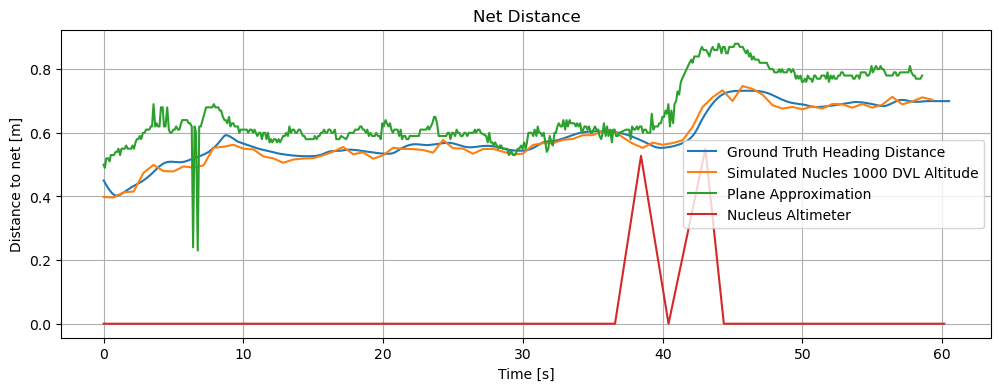

In [292]:
heading_dist_gt = get_profiler_data(SIM_BAG_PATH, "/heading_distance_ground_truth")
plane_approximation = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/navigation/plane_approximation")
normalize_time(plane_approximation)


plt.figure(figsize=(12, 4))
plt.plot(heading_dist_gt["time"], heading_dist_gt["ranges"], label="Ground Truth Heading Distance")
plt.plot(sim_dvl["t"].values, sim_dvl["altitude"].values, label="Simulated Nucles 1000 DVL Altitude")
# plt.plot(dvl_a50_velocity["t"].values, dvl_a50_velocity["altitude"].values, label="DVL-A50 Altitude")

plt.plot(plane_approximation["t"].values, plane_approximation["NetDistance"].values, label="Plane Approximation")


plt.plot(nucleus_alitmeter["t"].values, nucleus_alitmeter["altimeter_distance"].values, label="Nucleus Altimeter")



plt.title("Net Distance")
plt.xlabel("Time [s]")
plt.ylabel("Distance to net [m]")
plt.legend()
plt.grid()

Liten avvik i starten er mest sannsynlig på grunn av vinkelen på roven. Siden dvl har en vinkel på 4 beams.

# Pressure

/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:236: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')


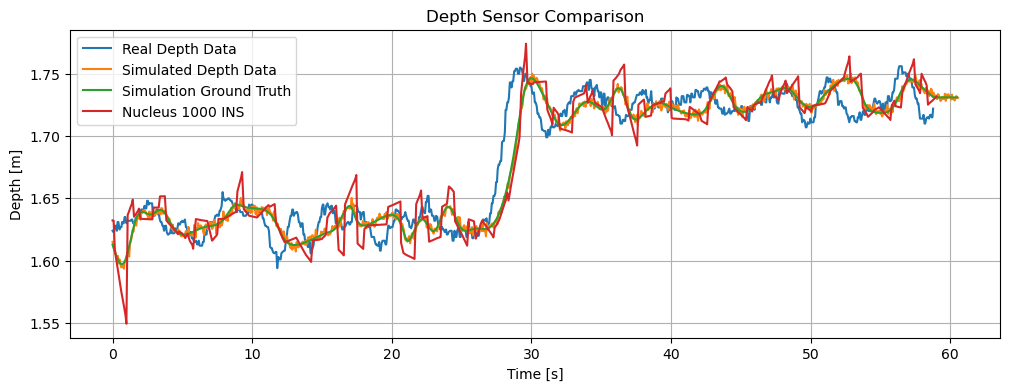

In [ ]:
# Read csv
real_depth_df = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/sensor/depth_temperature")
sim_depth_df = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/pressure")
sim_depth_gt_df = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/ground_truth")
normalize_time(real_depth_df)
normalize_time(sim_depth_df)
normalize_time(sim_depth_gt_df)

RHO = 1031 # [kg/m^3]
g = 9.81

# get array of data
depth_real = real_depth_df["depth"].values
depth_sim = (sim_depth_df["fluid_pressure"].values) / (RHO * g)


# Match mean values (depth differ slightly)
depth_sim -= depth_sim.mean()
depth_sim += depth_real.mean()


sim_depth_gt = sim_depth_gt_df["pose.pose.position.z"].values
sim_depth_gt -= sim_depth_gt.mean()
sim_depth_gt += depth_real.mean()


# PLOT
plt.figure(figsize=(12, 4))
plt.title("Depth Sensor Comparison")
plt.plot(real_depth_df["t"].values, depth_real, label="Real Depth Data")
plt.plot(sim_depth_df["t"].values, depth_sim, label="Simulated Depth Data")
plt.plot(sim_depth_gt_df["t"].values, sim_depth_gt, label="Simulation Ground Truth")



ins_depth = nucleus_ins["positionFrame.z"].values
ins_depth -= ins_depth.mean()
ins_depth += depth_real.mean()

plt.plot(nucleus_ins["t"].values, ins_depth, label="Nucleus 1000 INS")

plt.xlabel("Time [s]")
plt.ylabel("Depth [m]")
plt.legend()
plt.grid()
# plt.ylim(-0.35, -0.1)
plt.show()

# Temperature

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


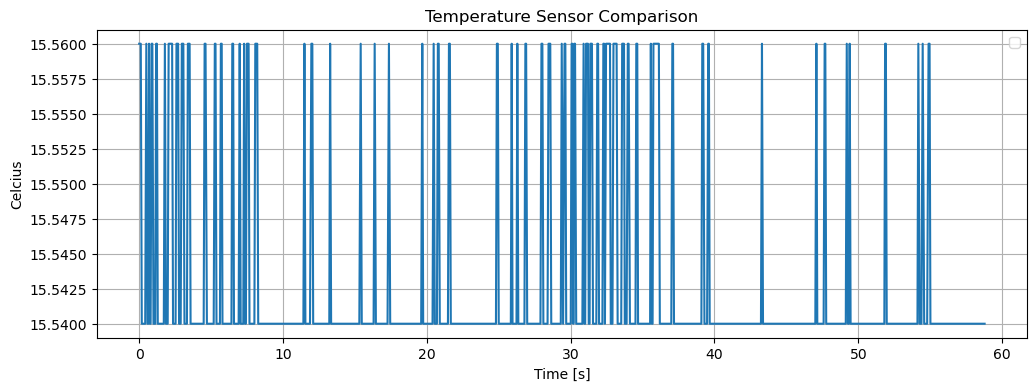

In [ ]:

plt.figure(figsize=(12, 4))
plt.title("Temperature Sensor Comparison")

plt.plot(real_depth_df["t"].values, real_depth_df["temperature"].values)


plt.xlabel("Time [s]")
plt.ylabel("Celcius")
plt.legend()
plt.grid()
# plt.ylim(-0.35, -0.1)
plt.show()